In [6]:
# Instalar las librerías necesarias
# !pip install pandas 
# !pip install seaborn

In [7]:
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.metrics import log_loss
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [8]:

triaje = pd.read_csv(
    "../datos/mimic-iv-ed-demo-2.2/mimic-iv-ed-demo-2.2/ed/triage.csv.gz"
)

df = triaje[triaje['acuity'].notna() & triaje['pain'].notna() &
            triaje['temperature'].notna() & triaje['heartrate'].notna() &
            triaje['o2sat'].notna()].drop(columns=['subject_id', 'stay_id']).copy()

# 0 = acuity 1-2, 1 = acuity 3-5 
y = (df['acuity'] < 3).astype(int).to_numpy()
print(np.unique(y, return_counts=True))

# diccionario para agrupar motivo de la consulta de la columna "chiefcomplaint"
# [sub] son palabras literales 
# [exact] son siglas que cuentan como una palabra completa
CONCEPTS = {
    'cc_arrest':   {'sub': ['arrest', 'intubat'], 'exact': []},
    'cc_neuro':    {'sub': ['droop', 'numb', 'weakness', 'dizz', 'diplopia', 'syncope', 'seizure',
                            'confusion', 'altered', 'letha', 'stroke', 'headache', 'hallucin',
                            'ambulate', 'tinnitus', 'head injury', 'head bleed'],
                    'exact': ['ams', 'cva', 'ich', 'sdh', 'sah']},
    'cc_cardiac':  {'sub': ['chest', 'palpitation', 'tachycardia', 'nstemi', 'aortic', 'atrial',
                            'ekg', 'hypertension', 'hypotension'], 'exact': []},
    'cc_resp':     {'sub': ['dyspnea', 'shortness', 'cough', 'hypox', 'laryngitis'],
                    'exact': ['sob', 'pe']},
    'cc_bleed':    {'sub': ['bleed', 'brbpr', 'hematemesis', 'hematuria', 'vomiting blood', 'emesis'],
                    'exact': []},
    'cc_metab':    {'sub': ['abnormal', 'lab', 'hyperglyc', 'hypoglyc', 'anemia', 'dehydrat',
                            'fatigue', 'hypotherm', 'neutropenia'],
                    'exact': ['dka', 'inr']},
    'cc_abd':      {'sub': ['abd', 'abdominal', 'n/v', 'nausea', 'vomit', 'diarrhea', 'epigastric',
                            'suprapubic', 'rlq', 'luq', 'ascites', 'rectal', 'urinary', 'dysuria',
                            'foley'], 'exact': []},
    'cc_infect':   {'sub': ['infect', 'fever', 'cellulitis', 'ulcer', 'abscess'],
                    'exact': ['ili']},
    'cc_trauma':   {'sub': ['fall', 'mvc', 'car vs', 'assault', 'injur', 'fracture', 'laceration',
                            'wound', 'trauma'], 'exact': ['fx']},
    'cc_psych':    {'sub': ['depress', 'anxiety', 'psych', 'etoh', 'overdose', 'insomnia'],
                    'exact': ['si']},
    'cc_vascular': {'sub': ['swelling'], 'exact': ['dvt']},
    'cc_localpain': {'sub': ['back', 'foot', 'knee', 'hand', 'shoulder', 'wrist', 'extremity'],
                     'exact': ['leg', 'arm', 'toe', 'rib', 'hip', 'ear', 'eye']},
    'cc_minor':    {'sub': ['eval', 'refill', 'picc', 'tube', 'hemodialysis', 'rash', 'allergic'],
                    'exact': []},
    'cc_transfer': {'sub': ['transfer'], 'exact': []},
    'cc_critical': {'sub': ['arrest', 'unresponsive', 'stroke', 'chest pain', 'shortness',
                            'seizure', 'bleeding'], 'exact': ['sob']},
}

# devuelve 1 si el texto contiene alguna palabra de [sub] o [exact] y 0 si no contiene
def has_concept(text, sub, exact):
    words = set(text.replace(',', ' ').replace('/', ' ').replace(';', ' ')
                    .replace('?', ' ').replace('-', ' ').replace('.', ' ').split())
    return int(any(k in text for k in sub) or any(w in words for w in exact))

# featuring 
VITALS = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']

# convertir el dataframe en una tabla numérica para darsela al modelo
# limpiar de nulos
# rellenar huecos de variables con medias

def build_features(raw, medians=None, use_cc=True):
    d = raw.copy()

    for c in VITALS:
        d[c] = pd.to_numeric(d[c], errors='coerce')

    if medians is None:
        medians = d[VITALS].median()

    out = pd.DataFrame(index=d.index)
    out['pain_missing'] = d['pain'].isna().astype(int)   # antes de rellenar
    d['pain'] = d['pain'].fillna(0)
    d[VITALS] = d[VITALS].fillna(medians)

    for c in VITALS:
        out[c] = d[c]

    # Derivadas (temperatura en °F)
    shock = d['heartrate'] / d['sbp'].replace(0, np.nan)
    # feature derivada de recuencia cardíaca / presión sistólica
    out['feat_shock_index'] = shock.fillna(medians['heartrate'] / medians['sbp'])
    # feature derivada que suma sbp y resprate
    out['feat_qsofa_score'] = (d['sbp'] <= 100).astype(int) + (d['resprate'] >= 22).astype(int)

    out['flag_fever']       = (d['temperature'] >= 100.4).astype(int)
    out['flag_hypothermia'] = (d['temperature'] < 95.0).astype(int)
    out['flag_hypoxia']     = (d['o2sat'] < 92.0).astype(int)
    out['flag_tachycardia'] = (d['heartrate'] > 100.0).astype(int)
    out['flag_bradycardia'] = (d['heartrate'] < 60.0).astype(int)
    out['flag_tachypnea']   = (d['resprate'] >= 22.0).astype(int)
    out['flag_hypotension'] = (d['sbp'] < 90.0).astype(int)
    out['flag_severe_pain'] = (d['pain'] >= 7.0).astype(int)

    # Conceptos del chiefcomplaint
    if use_cc:
        txt = d['chiefcomplaint'].fillna('').str.lower()
        for col, spec in CONCEPTS.items():
            out[col] = txt.apply(lambda t: has_concept(t, spec['sub'], spec['exact']))
        out['cc_unknown'] = txt.apply(lambda t: int(t == '' or 'unknown' in t or t == 'sw'))
        out['feat_cc_n_symptoms'] = txt.apply(lambda t: t.count(',') + t.count(';') + 1)

    return out.astype('float32'), medians

# split y entrenamiento
df_train, df_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y)

Xtr, med = build_features(df_train)
Xte, _   = build_features(df_test, medians=med)

# modelo

# RESULTADO Test loss: 0.620  Test accuracy: 0.605
# rf = RandomForestClassifier(
#     n_estimators=300, 
#     max_depth=5,
#     min_samples_leaf=3, 
#     random_state=42,
#     max_features='sqrt',
#     max_samples=0.9,
#     oob_score=True
# )


# RESULTADO Test loss: 0.631  Test accuracy: 0.553
# rf = RandomForestClassifier(
#     n_estimators=300, 
#     max_depth=5,
#     min_samples_leaf=6, 
#     random_state=42,
#     max_features='sqrt',
#     max_samples=0.7,
#     oob_score=True
# )

# RESULTADO Test loss: 0.621  Test accuracy: 0.632
# rf = RandomForestClassifier(
#     n_estimators=300, 
#     max_depth=5,
#     min_samples_leaf=1, 
#     random_state=42,
#     max_features='sqrt',
#     max_samples=0.7,
#     oob_score=True
# )

# RESULTADO Test loss: 0.635  Test accuracy: 0.684
rf = RandomForestClassifier(
    n_estimators=300, 
    max_depth=5,
    min_samples_leaf=2, 
    random_state=42,
    max_features='sqrt',
    max_samples=0.2,
    oob_score=True
)

rf.fit(Xtr, y_train)
print(f"Columnas: {Xtr.shape[1]}  Accuracy: {rf.score(Xte, y_test):.3f}")

# importancia relativa de cada variable dentro del modelo una vez entrenado
imp = pd.Series(rf.feature_importances_, index=Xtr.columns).sort_values(ascending=False)
print(imp.head(15))

test_accuracy = rf.score(Xte, y_test)
test_loss = log_loss(y_test, rf.predict_proba(Xte))
print(f"Test loss: {test_loss:.3f}  Test accuracy: {test_accuracy:.3f}")


# Evaluar diferentes hiperparámetros en el modelo
# from itertools import product

# grid = {
#     'max_depth':        [3, 5, 8],
#     'min_samples_leaf': [1, 3, 6],
#     'max_features':     ['sqrt', 0.5],
#     'max_samples':      [0.7, 0.9],
# }

# resultados = []
# for md, msl, mf, ms in product(*grid.values()):
#     m = RandomForestClassifier(
#         n_estimators=300, max_depth=md, min_samples_leaf=msl,
#         max_features=mf, max_samples=ms,
#         oob_score=True, random_state=42, n_jobs=-1
#     )
#     m.fit(Xtr, y_train)
#     resultados.append((m.oob_score_, md, msl, mf, ms))

# res = pd.DataFrame(resultados, columns=['oob', 'max_depth', 'min_samples_leaf',
#                                         'max_features', 'max_samples'])
# print(res.sort_values('oob', ascending=False).head(10))



(array([0, 1]), array([91, 99]))
Columnas: 35  Accuracy: 0.684
feat_shock_index      0.113828
heartrate             0.111079
sbp                   0.098486
dbp                   0.078505
temperature           0.076601
o2sat                 0.066778
pain                  0.066249
resprate              0.044937
cc_localpain          0.040169
cc_abd                0.034161
flag_severe_pain      0.033844
cc_metab              0.032897
feat_cc_n_symptoms    0.028513
cc_cardiac            0.027412
feat_qsofa_score      0.020007
dtype: float64
Test loss: 0.635  Test accuracy: 0.684


---

# Representación visual

Desde el modelo de logical regresion, mostrar resultados gráficamente.

### Imports de Librerías

In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

### Carda de dataset de triaje

In [3]:
# Carga de Triaje (Datos vitales sobre los pacientes)
triaje = pd.read_csv(
    "../datos/mimic-iv-ed-demo-2.2/mimic-iv-ed-demo-2.2/ed/triage.csv.gz"
)

# Carga de edstays (Datos sobre como llegan nuestros pacientes al hospital)
edstays = pd.read_csv(
    "../datos/mimic-iv-ed-demo-2.2/mimic-iv-ed-demo-2.2/ed/edstays.csv.gz",
    usecols=["stay_id", "intime", "arrival_transport"],
)

### Limpieza dataset

In [4]:
# Filtramos los valores nulos de 'acuity, temperature y heartrate' y eliminamos las columnas que contienen los IDs
df = triaje[triaje['acuity'].notna()].drop(columns=['subject_id', 'stay_id']).copy()

# Hacemos un merge de ambos Dataframes utilizando como clave 'stay_id', manteniendo todos los datos de 'triaje' con left join.
df = triaje[triaje["acuity"].notna()].merge(edstays, on="stay_id", how="left")

# Creamos la columna 'arrival_hour' a partir del valor intime que contiene la hora exacta de llegada, así no generamos ruido.
df["arrival_hour"] = pd.to_datetime(df["intime"]).dt.hour 

# Eliminamos las columnas que no nos proporcionan datos consistentes
df = df.drop(columns=["subject_id", "stay_id", "intime"])

# Obtenemos todos los valores de la columna 'pain' y cambiamos el typo que se ha encontrado por un 0.
pain_txt = df["pain"].astype("string").str.strip().str.lower().replace({"o": "0"})

# Guardamos la columna 'pain' en una variable pain_num, esta contendrá la columna 'pain' 
# construida en base a números y completamente normzaliada
pain_num = df["pain"] = pd.to_numeric(pain_txt, errors="coerce")


df["pain_not_assessable"] = (pain_txt.notna() & pain_num.isna()).astype(int)
df["pain"] = pain_num.where(pain_num.between(0, 10))

df

,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,arrival_transport,arrival_hour,pain_not_assessable
0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,2.0,"Abd pain, LEAKING ASCITES",AMBULANCE,22,0
1,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,2.0,"Dizziness, Diplopia",AMBULANCE,14,1
2,98.8,72.0,18.0,90.0,98.0,48.0,<NA>,2.0,Abd pain,UNKNOWN,23,0
3,97.8,115.0,20.0,99.0,92.0,42.0,0,2.0,"DKA, Transfer",AMBULANCE,6,0
4,98.1,95.0,18.0,99.0,149.0,74.0,0,2.0,Psych eval,WALK IN,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...
202,97.7,111.0,15.0,100.0,133.0,79.0,3,3.0,"Dehydration, Nausea, Rash",WALK IN,14,0
203,98.4,106.0,18.0,95.0,131.0,76.0,5,3.0,"Abd pain, Transfer",AMBULANCE,22,0
204,96.8,78.0,16.0,95.0,186.0,66.0,8,3.0,Abd pain,WALK IN,0,0
205,98.6,108.0,18.0,95.0,143.0,61.0,7,3.0,"Abd pain, Back pain",AMBULANCE,17,0


### Featuring Engineering sobre los datos que ya tenemos

In [5]:
# Hacemos Feature Engineering sobre los datos que ya tenemos filtrados

# Creamos un nuevo dato, el índice de shock, que supone la división de los latidos entre la presión arterial sistolica
df["shock_index"] = df["heartrate"] / df["sbp"]

# Obtenemos la presión del pulso a partir de la división de la presion arterial sistólica entre la diastólica
df["pulse_pressure"] = df["sbp"] - df["dbp"]

# Rellenamos los huecos vacíos con cadenas vacías, más adelante convertiremos esta columna en números para el modelo.
df["chiefcomplaint"] = df["chiefcomplaint"].fillna("")

### Preparación de observaciones para modelo y etiquetas

In [6]:
# Declaramos las columnas númericas 
numerical_columns = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain",
                     "pain_not_assessable", "shock_index", "pulse_pressure", "arrival_hour"]

# Definimos las observaciones
X = df[numerical_columns + ["arrival_transport", "chiefcomplaint"]]

# Definimos las etiquetas o los valores que tiene que predecir el modelo (Hacemos que 1 y 2 se normaicen a 0 y 3,4,5 se normalicen a 1)
y = (df["acuity"] <= 2).astype(int)

### Preparación de datos numéricos y texto por separado

In [7]:
# Declaramos la preparación que haremos sobre los datos
prep = make_column_transformer(
    # Con SimpleImputer rellenamos los huecos que no contengan números para no sesgar los datos
    (make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), numerical_columns),
    # Como en `arrival_transport` separamos en categorías, OneHotEncoder nos ayuda a separar las cateorías y transformarlas a números
    (OneHotEncoder(handle_unknown="ignore"), ["arrival_transport"]),
    # Normalizamos la columna de 'chiefcomplaint' estableciendo pesos según las repeticiones de las palabras
    (TfidfVectorizer(ngram_range=(1,2), min_df=2), "chiefcomplaint")
)

### Creación del modelo

In [8]:
# Declaramos el modelo que vamos a entrenar utilizando los datos que hemos preparado en los pasos anteriores, además utilizamos el algoritmo
# de LogisticRegression con un máximo de 5000 iteraciones sobre nuestros datos
model = make_pipeline(prep, LogisticRegression(max_iter=5000))

# Usamos RepeatedStratifiedKFold para recorrer los datos de múltiples maneras distintas y evaluar el modelo con mayor fiabilidad.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# Utilizamos GridSearchCV para poder especificar el modelo que vamos a entrenar y los hiperparámetros que vamos a utilizar
grid = GridSearchCV(
    model,
    {
        "logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "logisticregression__class_weight": ["balanced", None],
        "columntransformer__tfidfvectorizer__min_df": [1, 2, 3],
        # Especificamos las flags que vamos a usar a la hora de usar GridSearchCV
    }, cv=cv, scoring=["accuracy", "neg_log_loss"], n_jobs=-1, refit='neg_log_loss', verbose=3, return_train_score=True
)

### Entrenamiento del modelo

In [9]:
# Entrenamiento del modelo
grid.fit(X,y)

Fitting 15 folds for each of 42 candidates, totalling 630 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'columntransformer__tfidfvectorizer__min_df': [1, 2, ...], 'logisticregression__C': [0.01, 0.03, ...], 'logisticregression__class_weight': ['balanced', None]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'neg_log_loss']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_log_loss'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22

### Visualización de configuraciones generadas por el modelo de mayor a menor

In [10]:
# Creamos un Dataframe de pandas con todas las configuraciones que nos ha generado el entrenamiento
res = pd.DataFrame(grid.cv_results_)

configs_df = res[[
    "mean_test_accuracy",
    "mean_test_neg_log_loss",
    "param_logisticregression__C",
    "param_logisticregression__class_weight",
    "param_columntransformer__tfidfvectorizer__min_df"
]]

# Renombramos las columnas para una mejor legibilidad de los hiperparámetros utilizados en el entrenamiento
configs_df = configs_df.rename(columns={'logisticregression__C':'C', 
                                        'param_logisticregression__class_weight': 'class_weight',
                                        'param_columntransformer__tfidfvectorizer__min_df': 'min_df' })

# Transformamos la pérdida a positivo
configs_df['mean_test_neg_log_loss'] = -res['mean_test_neg_log_loss']

# Mostramos los valores ordenados de mayor a menor
configs_df.sort_values('mean_test_accuracy', ascending=False)[:10]

,mean_test_accuracy,mean_test_neg_log_loss,param_logisticregression__C,class_weight,min_df
39,0.705381,0.616348,3.0,NaN,3
25,0.702245,0.611404,3.0,NaN,2
9,0.702207,0.604196,1.0,NaN,1
37,0.700658,0.595383,1.0,NaN,3
23,0.700581,0.594130,1.0,NaN,2
41,0.697406,0.673157,10.0,NaN,3
35,0.694464,0.589992,0.3,NaN,3
11,0.694154,0.625343,3.0,NaN,1
21,0.692722,0.591258,0.3,NaN,2
38,0.690979,0.617411,3.0,balanced,3


### Visualización comparación de modelos

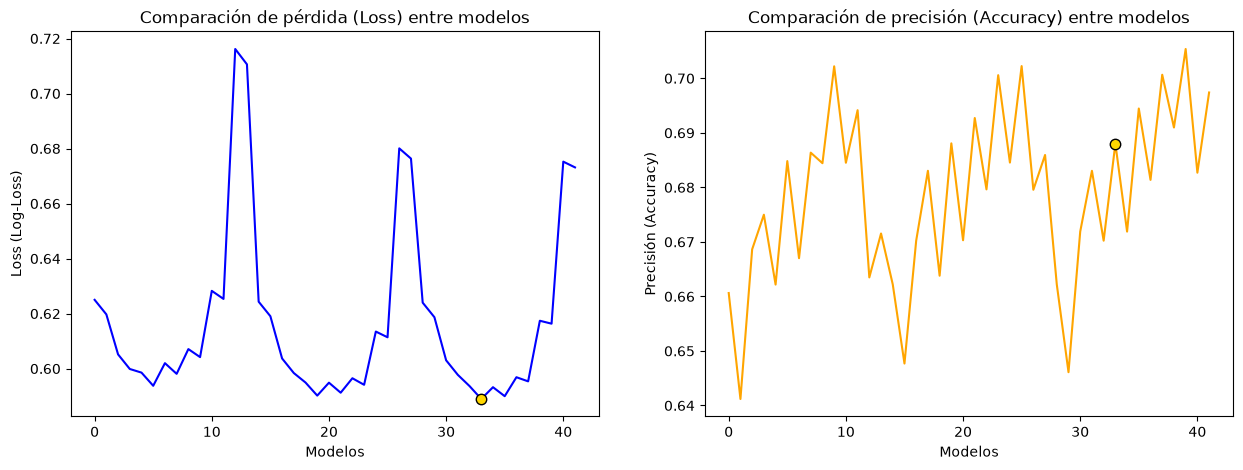

In [31]:
# Extraer valores de todas las combinaciones
accuracy_list = res["mean_test_accuracy"]
loss_list = -res["mean_test_neg_log_loss"]

# Crear índice para eje X donde irán los modelos entrenados
model_indices = range(len(res))

# Obtener índice del mejor modelo de los 42 según (refit:'neg_log_loss')
best_model_index = grid.best_index_

# Gráfico
plt.figure(figsize=(15,5))

# Gráfico 1: Comparando pérdida entre modelos
plt.subplot(1,2,1)
plt.plot(model_indices, loss_list, color='blue')
plt.plot(best_model_index, loss_list[best_model_index], marker=".", markersize=15, color="gold", markeredgecolor="black", label="Mejor modelo")
plt.xlabel("Modelos")
plt.ylabel("Loss (Log-Loss)")
plt.title("Comparación de pérdida (Loss) entre modelos")

# Gráfico 2: Comparando precisión entre modelos
plt.subplot(1,2,2)
plt.plot(model_indices, accuracy_list, color='orange')
plt.plot(best_model_index, accuracy_list[best_model_index], marker=".", markersize=15, color="gold", markeredgecolor="black", label="Mejor modelo")
plt.xlabel("Modelos")
plt.ylabel("Precisión (Accuracy)")
plt.title("Comparación de precisión (Accuracy) entre modelos")

plt.show()

### Visualización de puntuaciones (Función de pérdida y precisión)

In [27]:
# Declaramos la combinación final que hemos elegido en base a la tabla de configuraciones qie ha generado el entrenamiento
final_params = {
    "columntransformer__tfidfvectorizer__min_df": 2,
    "logisticregression__C": 1,
    "logisticregression__class_weight": None,
}

# Obtenemos el índice de la combinación que queremos utilizar como defnitiva
i = grid.cv_results_['params'].index(final_params)

# Obtenemos precisión y pérdida del modelo.
accuracy = grid.cv_results_['mean_test_accuracy'][i]
loss = -grid.cv_results_['mean_test_neg_log_loss'][i]

# Los mostramos por pantalla.
print(f'Accuraccy: {accuracy}')
print(f'Loss: {loss}')

Accuraccy: 0.7005807200929152
Loss: 0.5941297158102188
